# Imports

In [104]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import axes


# Load data

In [105]:
games_odds = pd.read_csv("data/game_odds.csv")
games_index = pd.read_csv("data/games_index.csv")
games_schedule = pd.read_csv("data/games_schedule.csv")

player_boxscores = pd.read_csv("data/player_boxscores.csv")
team_boxscores = pd.read_csv("data/team_boxscores.csv")



In [106]:
play_by_play = pd.read_csv("data/play_by_play.csv")

In [107]:
# print("Game Odds:")
# display(games_odds.head())
# print("Games Index:")
# display(games_index.head())
# print("Games Schedule:")
# display(games_schedule.head())
# print("Play-by-Play:")
# display(play_by_play.head())
# print("Player Boxscores:")
# display(player_boxscores.head())
# print("Team Boxscores:")
# display(team_boxscores.head())


# Clean data

In [108]:
#get rid of nan values in the datasets
games_odds = games_odds.dropna()
games_index = games_index.dropna()
games_schedule = games_schedule.dropna()
#play_by_play = play_by_play.dropna() # don't drop because it'll drop every row that's not a shoot, because the subtype column is "Unknown" for every action that's not a shoot, and we need to keep those actions to be able to analyze the best players
player_boxscores = player_boxscores.dropna()
team_boxscores = team_boxscores.dropna()

# See data

In [109]:
#get all action types ranked by number of occurences in the play_by_play dataset
action_types_count = play_by_play['action_type'].value_counts().reset_index()
action_types_count.columns = ['action_type', 'count']
print("Action types ranked by number of occurences:")
display(action_types_count)

Action types ranked by number of occurences:


,action_type,count
0,Rebound,3875782
1,Missed Shot,3438449
2,Made Shot,2876536
3,Free Throw,1814470
4,Foul,1638822
5,Substitution,1587239
6,Turnover,1094685
7,Timeout,479197
8,period,308364
9,Violation,66914


# Players analysis

## Addapt the players names difference btw the files

In [110]:
# in play_by_play : names are in the format "L. James" instead of "LeBron James"
# let's add a new column player_full_name using the dict_player_names dictionary
dict_player_names = {
    'A. Abrines' : "Alex Abrines",
    'A. Acker' : "Anthony Acker",
    'A. Afflalo' : "Arron Afflalo",
    'A. Ajinca' : "Alexis Ajinca",
    'A. Amaya' : "Ashraf Amaya",
    'A. Aminu' : "Al-Farouq Aminu",

    'A. Anderson' : "Alan Anderson",
    'A. Antetokounmpo' : "Alex Antetokounmpo",
    'A. Avent' : "Anthony Avent",
    'A. Bailey' : "Anthony Bailey",
    'A. Bal' : "Anthony Bal",
    'A. Caver' : "Alex Caver",
    'A. Davis' : "Anthony Davis",
    'A. Drummond' : "Andre Drummond",
    'A. Iverson' : "Allen Iverson",
    'A. Johnson' : "Alvin Johnson",
    'B. Wallace' : "Bradley Wallace",
    'C. Anthony' : "Carmelo Anthony",
    'C. Paul' : "Chris Paul",
    'D. DeRozan' : "DeMar DeRozan",
    'D. Green' : "Danny Green",
    'D. Howard' : "Dwight Howard",
    'D. Jordan' : "Derrick Jordan",
    'D. Nowitzki' : "Dirk Nowitzki",
    'D. Skapintsev' : "Dmitry Skapintsev",
    'D. Wade' : "Dwyane Wade",
    'D. West' : "Devin West",
    'G. Antetokounmpo' : "Giannis Antetokounmpo",
    'G. Hill' : "George Hill",
    'G. Lawal' : "Gani Lawal",
    'G. Rucker' : "Gary Rucker",
    'J. Crutcher' : "Jalen Crutcher",
    'J. Green' : "Jeff Green",
    'J. Harden' : "James Harden",
    'J. Holiday' : "Jrue Holiday",
    'J. Howard' : "Jarrett Howard",
    'J. Johnson' : "John Johnson",
    "J. O'Brien" : "James O'Brien",
    'J. Sibert' : "Jared Sibert",
    'J. Smith' : "John Smith",
    'J. Williams' : "John Williams",
    'K. Bryant' : "Kobe Bryant",
    'K. Durant' : "Kevin Durant",
    'K. Garnett' : "Kevin Garnett",
    'K. Irving' : "Kyrie Irving",
    'K. Leonard' : "Kawhi Leonard",
    'K. Martin' : "Kevin Martin",
    'K. Thomas' : "Kemba Thomas",
    'L. Aldridge ' : "LaMarcus Aldridge",
    'L. Dončić' : "Luka Dončić",
    'L. James' : "LeBron James",
    'M. Williams' : "Michael Williams",
    'P. Gasol' : "Pau Gasol",
    'P. Pierce' : "Paul Pierce",
    'R. Allen' : "Ray Allen",
    'R. Gobert' : "Rudy Gobert",
    'R. Hearn' : "Randy Hearn",
    'R. Westbrook' : "Russell Westbrook",
    'S. Curry' : "Stephen Curry",
    'S. Gilleous-Alexander' : "Shai Gilgeous-Alexander",
    'S. Marion' : "Shawn Marion",
    "S. O'Neal" : "Shaquille O'Neal",
    'S. Vranes' : "Sasha Vranes",
    'T. Chandler' : "Tyrone Chandler",
    'T. Duncan' : "Tim Duncan",
    'T. Young' : "Trae Young",
    'V. Carter' : "Vince Carter",
    'Z. Randolph' : "Zach Randolph"
}

#drop rows where player_name_i is nan
play_by_play = play_by_play.dropna(subset=['player_name_i'])

# create a new column in play_by_play with the full player name
play_by_play["player_full_name"] = play_by_play["player_name_i"].map(dict_player_names)
# if name is not in the dict print "Player name not found in dict:", player_name_i
not_found_names = [player_name_i for player_name_i in play_by_play["player_name_i"] if player_name_i not in dict_player_names]



In [111]:
# print the count of each name in the not_found_names list
not_found_names_count = pd.Series(not_found_names).value_counts()
print("Player names not found in dict and their count:")
# display ordered by alphabetical order
not_found_names_count = not_found_names_count.sort_index()
display(not_found_names_count.head(20))



Player names not found in dict and their count:


A. Bargnani    15386
A. Barrett       571
A. Baynes       9581
A. Bennett      1895
A. Biedrins    11738
A. Black        4628
A. Blakeney     1038
A. Blatche     14390
A. Bogut       22078
A. Bona         2180
A. Bonner         23
A. Bowie         207
A. Bradley     14766
A. Bramlett       66
A. Brimah         41
A. Brooks      13137
A. Brown        1017
A. Burks       17200
A. Bynum       14060
A. Caldwell      585
Name: count, dtype: int64

## Player_boxscores

### preparation : dict for column names + aggregate

In [112]:
stat_columns_player_boxscores = {
        "pts":   "points",
        "reb":   "rebounds",
        "ast":   "assists",
        "stl":   "steals",
        "blk":   "blocks",
        "tov":   "turnovers",
        "min":   "minutes",
        "fgm":   "Field Goals Made",
        "fga":   "Field Goals Attempted",
        "fg3m":  "Three Pointers Made",
        "fg3a":  "Three Pointers Attempted",
        "ftm":   "Free Throws Made",
        "fta":   "Free Throws Attempted",
        "plus_minus": "impact of player on team performance",
        "dreb":  "defensive rebounds",
        "oreb":  "offensive rebounds",
    }
available = {k: v for k, v in stat_columns_player_boxscores.items() if k in player_boxscores.columns}
player_wins_per_team = (
        player_boxscores.groupby(["player_id", "player_name", "team_abbreviation"], as_index=False)
          .agg(
              games=("game_id", "nunique"),
              **{v: (k, "mean") for k, v in available.items()}
          )
    )
# print("Aggregated Player Stats:")
# display(player_wins_per_team)

### Player_boxscores get top_players_points_avg, top_player_rebounds, top_player_assists

In [113]:
# Plotting average points per game for top 20 players
top_players_points_avg = player_wins_per_team.sort_values(by="points", ascending=False).head(20)

#print(top_players_avg[["player_name", "points", "team_abbreviation"]])


top_player_rebounds_avg = player_wins_per_team.sort_values(by="rebounds", ascending=False).head(20)
top_player_assists_avg = player_wins_per_team.sort_values(by="assists", ascending=False).head(20)

### Plot data : avg points per game, avg points + avg rebounds + avg assists per game

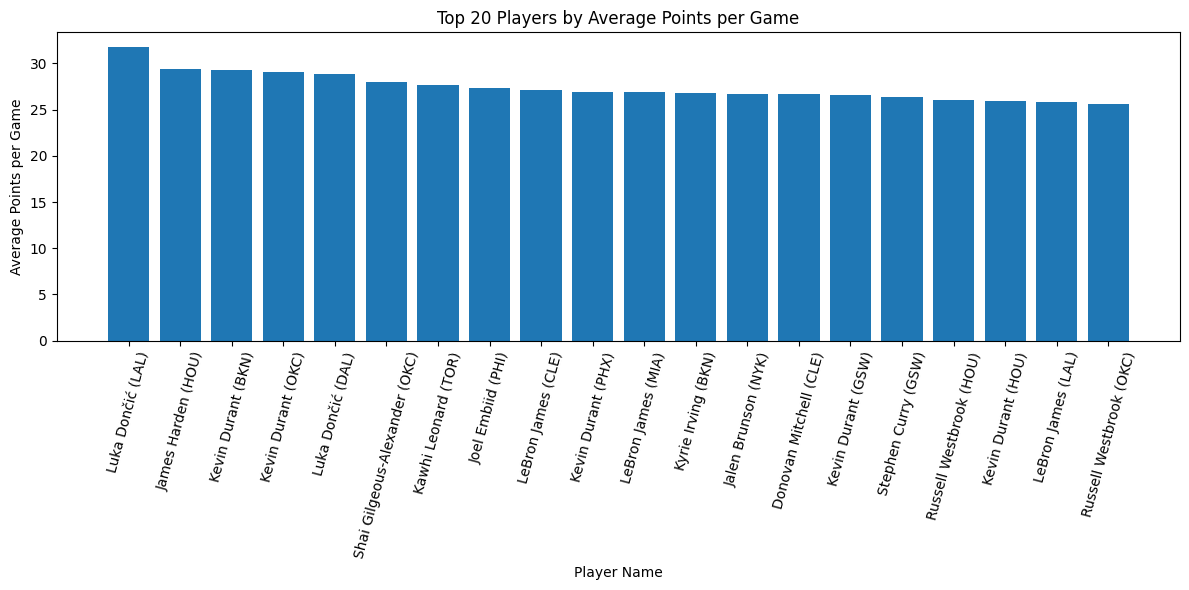

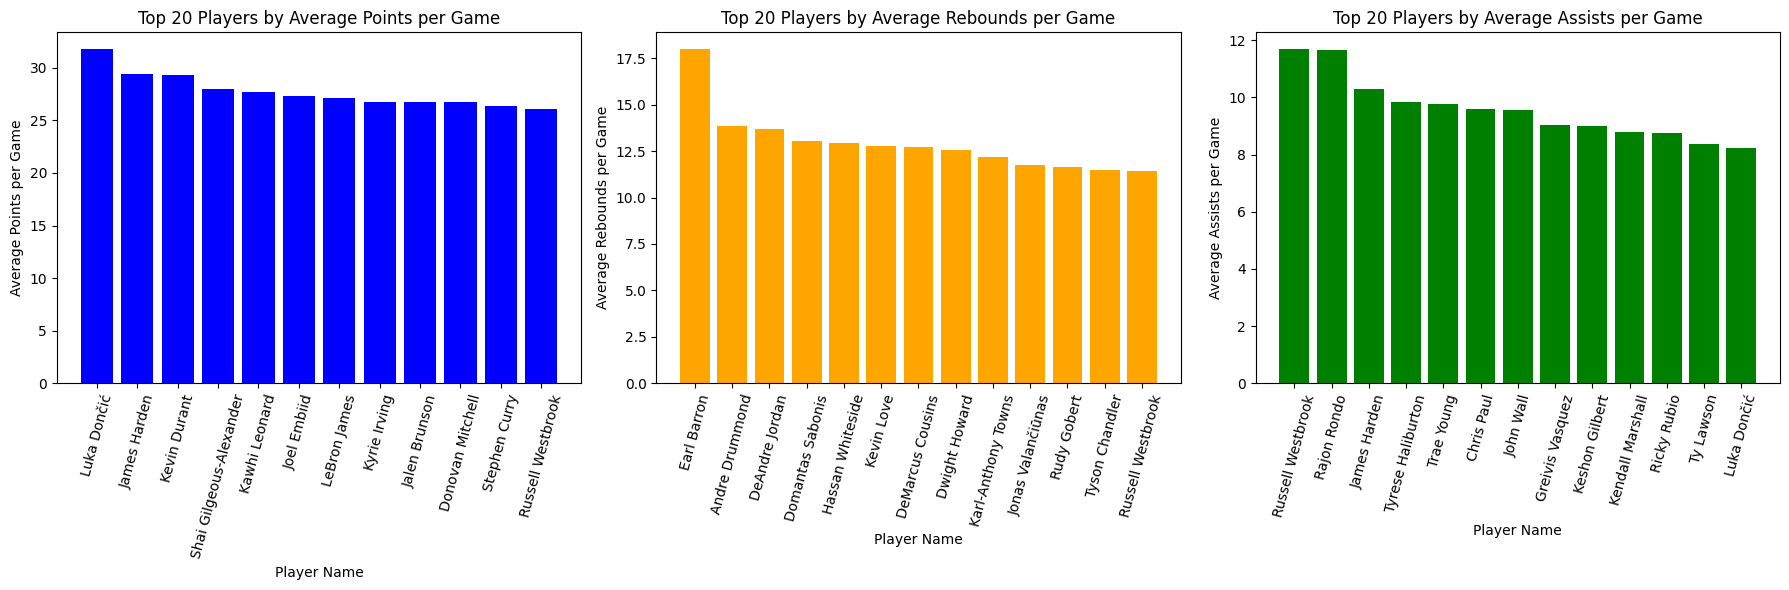

In [114]:
# Plotting average points per game for top 10 players without taking into account the team they played for
plt.figure(figsize=(12, 6))
plt.bar(top_players_points_avg["player_name"] + " (" + top_players_points_avg["team_abbreviation"] + ")", top_players_points_avg["points"])
plt.xlabel("Player Name")
plt.ylabel("Average Points per Game")
plt.title("Top 20 Players by Average Points per Game")
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()


# plot better players by points, rebounds and assists
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].bar(top_players_points_avg["player_name"], top_players_points_avg["points"], color='blue')
axes[0].set_xlabel("Player Name")
axes[0].set_ylabel("Average Points per Game")
axes[0].set_title("Top 20 Players by Average Points per Game")
axes[0].tick_params(axis='x', rotation=75)
axes[1].bar(top_player_rebounds_avg["player_name"], top_player_rebounds_avg["rebounds"], color='orange')
axes[1].set_xlabel("Player Name")
axes[1].set_ylabel("Average Rebounds per Game")
axes[1].set_title("Top 20 Players by Average Rebounds per Game")
axes[1].tick_params(axis='x', rotation=75)
axes[2].bar(top_player_assists_avg["player_name"], top_player_assists_avg["assists"], color='green')
axes[2].set_xlabel("Player Name")
axes[2].set_ylabel("Average Assists per Game")
axes[2].set_title("Top 20 Players by Average Assists per Game")
axes[2].tick_params(axis='x', rotation=75)
plt.tight_layout()
plt.show()



### Player by team and season

In [115]:
# print player name, team abreviation, season from player_boxscores dataset
print("Player name, team abreviation, season from player_boxscores dataset:")
display(player_boxscores[['player_name', 'team_abbreviation', 'season']].head())

Player name, team abreviation, season from player_boxscores dataset:


KeyError: "['season'] not in index"

### Best Shooter (points + nb of shoots made) (shoot made = panier marqué)

2877105
     player_name_i  shot_value
1468      L. James     41029.0
1238      J. Smith     37411.0
2089      S. Curry     31164.0
1319     K. Bryant     29536.0
1333     K. Durant     28583.0
1118    J. Johnson     27556.0
296     C. Anthony     26950.0
623    D. Nowitzki     26733.0
1078      J. Green     25752.0
2242     T. Duncan     24529.0
1734   M. Williams     23799.0
1083     J. Harden     23534.0
2057  R. Westbrook     23344.0
2370      T. Young     23081.0
1343    K. Garnett     22581.0
1917      R. Allen     22348.0
680        D. Wade     22214.0
2383     V. Carter     22067.0
39        A. Davis     21882.0
1879     P. Pierce     21772.0


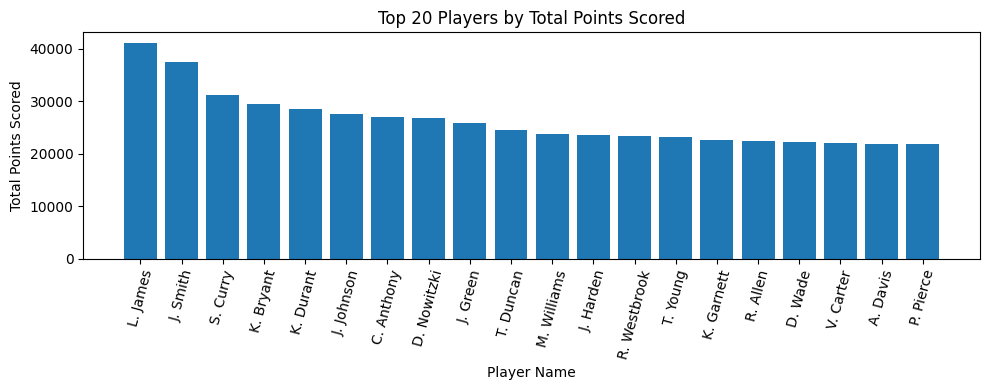

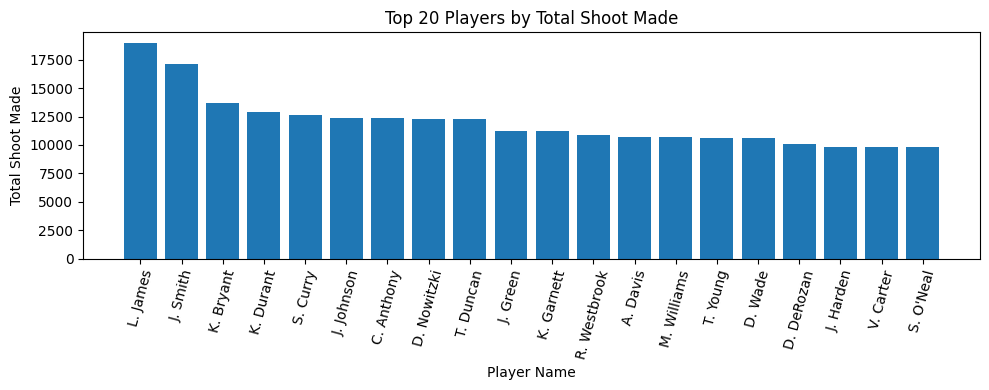

In [ ]:
all_shoots_made = play_by_play[play_by_play['shot_result'] == 'Made']
#display(play_by_play[['shot_result', 'shot_value']].head(50))

# all points scored by each player in the dataset
player_points_total = all_shoots_made.groupby("player_name_i")["shot_value"].sum().reset_index()
player_points_total = player_points_total.sort_values(by="shot_value", ascending=False)

print(all_shoots_made.shape[0])
print(player_points_total.head(20))

#plotting the top 20 players by total points scored in the dataset
plt.figure(figsize=(10, 4))
plt.bar(player_points_total["player_name_i"].head(20), player_points_total["shot_value"].head(20))
plt.xlabel("Player Name")
plt.ylabel("Total Points Scored")
plt.title("Top 20 Players by Total Points Scored")
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

# nb of shoot made by each player in the dataset
player_shoot_made = all_shoots_made.groupby("player_name_i")["shot_value"].count().reset_index()
player_shoot_made = player_shoot_made.sort_values(by="shot_value", ascending=False)

plt.figure(figsize=(10, 4))
plt.bar(player_shoot_made["player_name_i"].head(20), player_shoot_made["shot_value"].head(20))
plt.xlabel("Player Name")
plt.ylabel("Total Shoot Made")
plt.title("Top 20 Players by Total Shoot Made")
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()




In [ ]:
player_shoot_made_full_name = player_shoot_made.copy()
for i in range(len(player_shoot_made_full_name)):
    player_name_i = player_shoot_made_full_name.loc[i, "player_name_i"]
    if player_name_i in dict_player_names:
        player_shoot_made_full_name.loc[i, "player_name_i"] = dict_player_names[player_name_i]


# check if a player is in the player_shoot_made and top_players_avg
best_shooter_players = set(player_shoot_made_full_name["player_name_i"].head(20)).intersection(set(top_players_avg["player_name"].head(20)))
print("Players in both top 20 lists (aka best shooters):", best_shooter_players)

Players in both top 20 lists (aka best shooters): {'Stephen Curry', 'Kevin Durant', 'James Harden', 'Russell Westbrook', 'LeBron James'}


In [ ]:
play_by_play_columns = ['game_id', 'game_date', 'game_matchup', 'team_id', 'person_id',
       'action_id', 'action_number', 'clock', 'period', 'team_tri_code',
       'player_name', 'player_name_i', 'xlegacy', 'ylegacy', 'shot_distance',
       'shot_result', 'is_field_goal', 'score_home', 'score_away',
       'points_total', 'location', 'description', 'action_type', 'subtype',
       'video_available', 'shot_value']

### 

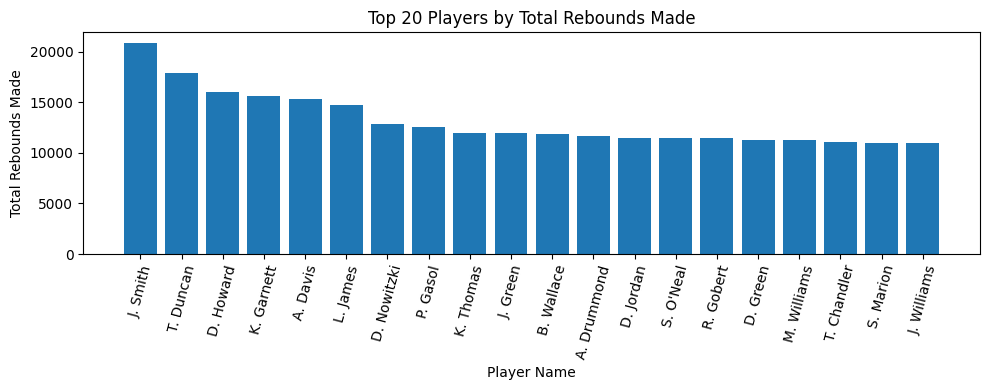

         player_name_i  shot_value
1249        John Smith       20893
2263        Tim Duncan       17906
575      Dwight Howard       16051
1357     Kevin Garnett       15681
38       Anthony Davis       15293
1484      LeBron James       14759
628      Dirk Nowitzki       12835
1881         Pau Gasol       12545
1434      Kemba Thomas       11943
1089        Jeff Green       11935
285    Bradley Wallace       11923
45      Andre Drummond       11711
589     Derrick Jordan       11529
2183  Shaquille O'Neal       11485
1984       Rudy Gobert       11472
556        Danny Green       11289
1755  Michael Williams       11243
2249   Tyrone Chandler       11072
2167      Shawn Marion       11034
1305     John Williams       10971
Players in both top 20 lists (aka best rebounders): {'Rudy Gobert', 'Dwight Howard', 'Andre Drummond'}


In [ ]:
#get all rebound rows
all_rebounds_made = play_by_play[play_by_play['action_type'] == 'Rebound']
all_rebounds_made = all_rebounds_made.sort_values(by="shot_value", ascending=False)

# print()
# print(top_player_rebounds[["player_name", "rebounds", "team_abbreviation"]].head(20))


#get most rebound players on play_by_play dataset
player_rebounds_made = all_rebounds_made.groupby("player_name_i")["shot_value"].count().reset_index()
player_rebounds_made = player_rebounds_made.sort_values(by="shot_value", ascending=False)
plt.figure(figsize=(10, 4))
plt.bar(player_rebounds_made["player_name_i"].head(20), player_rebounds_made["shot_value"].head(20))
plt.xlabel("Player Name")
plt.ylabel("Total Rebounds Made")
plt.title("Top 20 Players by Total Rebounds Made")
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

# check if a player is in the player_rebounds_made and top_player_rebounds
player_rebounds_made_full_name = player_rebounds_made.copy()
for i in range(len(player_rebounds_made_full_name)):
    player_name_i = player_rebounds_made_full_name.loc[i, "player_name_i"]
    if player_name_i in dict_player_names:
        player_rebounds_made_full_name.loc[i, "player_name_i"] = dict_player_names[player_name_i]
print(player_rebounds_made_full_name.head(20))

best_rebound_players = set(player_rebounds_made_full_name["player_name_i"].head(20)).intersection(set(top_player_rebounds["player_name"].head(20)))
print("Players in both top 20 lists (aka best rebounders):", best_rebound_players)



## Star players

In [ ]:
best_shooter_players, best_rebound_players, best_assist_players

star_players = []

star_players.append(best_shooter_players)

# Teams analysis

## Preparation

### Dictionary teams name - abreviation

In [125]:
teams_dict = {
    "ATL": "Atlanta Hawks",
    "BOS": "Boston Celtics",
    "BKN": "Brooklyn Nets",
    "CHA": "Charlotte Hornets",
    "CHI": "Chicago Bulls",
    "CLE": "Cleveland Cavaliers",
    "DAL": "Dallas Mavericks",
    "DEN": "Denver Nuggets",
    "DET": "Detroit Pistons",
    "GSW": "Golden State Warriors",
    "HOU": "Houston Rockets",
    "IND": "Indiana Pacers",
    "LAC": "Los Angeles Clippers",
    "LAL": "Los Angeles Lakers",
    "MEM": "Memphis Grizzlies",
    "MIA": "Miami Heat",
    "MIL": "Milwaukee Bucks",
    "MIN": "Minnesota Timberwolves",
    "NOP": "New Orleans Pelicans",
    "NYK": "New York Knicks",
    "OKC": "Oklahoma City Thunder",
    "ORL": "Orlando Magic",
    "PHI": "Philadelphia 76ers",
    "PHX": "Phoenix Suns",
    "POR": "Portland Trail Blazers",
    "SAC": "Sacramento Kings",
    "SAS": "San Antonio Spurs",
    "TOR": "Toronto Raptors",
    "UTA": "Utah Jazz",
    "WAS": "Washington Wizards"
}

name_to_abbreviation = {v: k for k, v in teams_dict.items()}

In [126]:
#game_index : add team_abbreviation_home, team_abbreviation_away from teams_dict
games_index["team_abbreviation_home"] = games_index["team_name_home"].map(name_to_abbreviation)
games_index["team_abbreviation_away"] = games_index["team_name_away"].map(name_to_abbreviation)

### Aggregations from team_boxscores

In [127]:
#teams aggregate stats from team boxscores
team_agg_summary = (
        team_boxscores.groupby(["team_id", "team_abbreviation"], as_index=False)
            .agg(
                games=("game_id", "nunique"),
                **{v: (k, "mean") for k, v in available.items()}
            )
    )
print("Aggregated Team Stats:")
display(team_agg_summary)

print()
# teams aggregate stats per season from team boxscores
team_agg_summary_per_season = (
        team_boxscores.groupby(["team_id", "team_abbreviation", "season_year"], as_index=False)
            .agg(
                games=("game_id", "nunique"),
                **{v: (k, "mean") for k, v in available.items()}
            )
    )
print("Aggregated Team Stats per Season:")
display(team_agg_summary_per_season)

Aggregated Team Stats:


,team_id,team_abbreviation,games,points,rebounds,assists,steals,blocks,turnovers,minutes,Field Goals Made,Field Goals Attempted,Three Pointers Made,Three Pointers Attempted,Free Throws Made,Free Throws Attempted,impact of player on team performance,defensive rebounds,offensive rebounds
0,1610612737,ATL,1085,109.835023,43.332719,25.323502,8.082028,4.726267,14.525346,48.331797,40.452535,87.922581,11.569585,32.495853,17.360369,22.230415,-1.129954,32.987097,10.345622
1,1610612738,BOS,1186,109.604553,44.387015,24.345700,7.478921,5.090219,13.402192,48.383642,40.123103,87.436762,12.606239,34.778246,16.752108,21.101180,4.333895,34.005902,10.381113
2,1610612739,CLE,1129,108.027458,43.221435,23.714792,7.309123,4.126661,13.985828,48.301151,39.765279,85.876882,11.419841,31.554473,17.077059,22.328609,0.511957,32.635961,10.585474
3,1610612740,NOH,52,94.884615,41.461538,21.769231,6.788462,5.634615,14.596154,48.384615,36.365385,81.000000,6.961538,18.615385,15.192308,19.615385,-4.019231,29.288462,12.173077
4,1610612740,NOP,963,110.494289,44.541018,25.105919,7.977155,5.067497,14.272066,48.321881,41.132918,88.269990,10.475597,29.461059,17.752856,23.224299,-1.396677,33.664590,10.876428
5,1610612741,CHI,1046,106.737094,44.124283,24.222753,7.473231,4.705545,14.130975,48.425430,39.858509,87.309751,10.347036,29.009560,16.673040,21.214149,-2.121415,33.792543,10.331740
6,1610612742,DAL,1050,109.115238,42.574286,23.422857,7.051429,4.460000,12.966667,48.338095,39.909524,86.469524,12.152381,33.868571,17.143810,22.346667,0.154286,33.140000,9.434286
7,1610612743,DEN,1147,111.462075,44.653880,26.292938,7.534438,4.707934,14.121186,48.366160,41.502180,87.429817,10.893636,29.946818,17.564080,22.933740,1.973845,33.526591,11.127289
8,1610612744,GSW,1159,112.471959,44.488352,27.697153,8.258844,5.229508,14.881795,48.284728,41.380500,87.853322,13.015531,34.733391,16.695427,21.310613,3.864538,34.151855,10.336497
9,1610612745,HOU,1125,110.715556,44.351111,22.722667,8.255111,4.936000,14.960000,48.306667,39.561778,87.018667,12.745778,36.425778,18.846222,25.228444,1.056889,33.106667,11.244444



Aggregated Team Stats per Season:


,team_id,team_abbreviation,season_year,games,points,rebounds,assists,steals,blocks,turnovers,minutes,Field Goals Made,Field Goals Attempted,Three Pointers Made,Three Pointers Attempted,Free Throws Made,Free Throws Attempted,impact of player on team performance,defensive rebounds,offensive rebounds
0,1610612737,ATL,2012-13,63,97.206349,41.349206,23.777778,8.301587,4.539683,14.555556,48.555556,37.285714,81.619048,8.317460,23.206349,14.317460,20.396825,0.301587,31.698413,9.650794
1,1610612737,ATL,2013-14,63,98.365079,39.825397,23.777778,8.126984,3.920635,15.047619,48.396825,36.031746,81.619048,9.031746,26.190476,17.269841,21.952381,-1.142857,30.809524,9.015873
2,1610612737,ATL,2014-15,70,101.042857,41.157143,24.842857,8.757143,4.828571,14.171429,48.285714,37.642857,82.542857,9.471429,26.385714,16.285714,20.900000,3.214286,32.128571,9.028571
3,1610612737,ATL,2015-16,69,101.768116,41.710145,25.246377,9.072464,5.884058,14.869565,48.434783,38.275362,84.608696,9.695652,28.695652,15.521739,19.768116,1.884058,33.449275,8.260870
4,1610612737,ATL,2016-17,66,102.621212,43.848485,23.621212,8.060606,4.606061,15.954545,48.454545,37.712121,84.257576,8.893939,26.333333,18.303030,24.636364,-1.075758,33.545455,10.303030
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
415,1610612766,CHA,2021-22,83,115.180723,44.530120,28.000000,8.566265,4.891566,13.265060,48.481928,42.674699,91.409639,13.927711,38.204819,15.903614,21.469880,0.084337,33.698795,10.831325
416,1610612766,CHA,2022-23,82,110.951220,44.536585,25.146341,7.731707,5.182927,14.195122,48.365854,41.280488,90.402439,10.743902,32.548780,17.646341,23.560976,-6.243902,33.548780,10.987805
417,1610612766,CHA,2023-24,82,106.585366,40.280488,24.792683,6.853659,4.524390,13.768293,48.121951,40.012195,86.987805,12.060976,34.000000,14.500000,18.439024,-10.243902,30.951220,9.329268
418,1610612766,CHA,2024-25,82,105.097561,45.195122,24.317073,7.402439,4.487805,15.500000,48.182927,38.317073,89.121951,12.987805,38.329268,15.475610,19.768293,-9.109756,32.963415,12.231707


### Aggregation from games_index

In [133]:
#teams aggregate stats per season from games_index
# "game_id","team_name_home", "team_name_away","winner", "season_year"
team_agg_summary_per_season_games_index = (
        games_index.groupby(["game_id","team_name_home", "team_name_away","winner", "season_year"], as_index=False)
            .agg(
                games=("game_id", "nunique"),
            )
    )
print("Aggregated Team Stats per Season from games_index:")
display(team_agg_summary_per_season_games_index)

Aggregated Team Stats per Season from games_index:


,game_id,team_name_home,team_name_away,winner,season_year,games
0,20000001,New York Knicks,Philadelphia 76ers,PHI,2000-01,1
1,20000002,New Jersey Nets,Cleveland Cavaliers,CLE,2000-01,1
2,20000003,Orlando Magic,Washington Wizards,ORL,2000-01,1
3,20000004,Atlanta Hawks,Charlotte Hornets,CHH,2000-01,1
4,20000005,Toronto Raptors,Detroit Pistons,DET,2000-01,1
...,...,...,...,...,...,...
37981,52500111,Charlotte Hornets,Miami Heat,CHA,2025-26,1
37982,52500121,Phoenix Suns,Portland Trail Blazers,POR,2025-26,1
37983,52500131,LA Clippers,Golden State Warriors,GSW,2025-26,1
37984,52500201,Orlando Magic,Charlotte Hornets,ORL,2025-26,1


In [135]:
#count nb games per season from games_index
games_per_season = games_index.groupby("season_year")["game_id"].nunique().reset_index().sort_values(by="season_year", ascending=True)
print("Number of games per season from games_index:")
#display(games_per_season)

# count nb games per season per team from games_index
games_per_season_per_team = games_index.groupby(["season_year", "team_name_home"])["game_id"].nunique().reset_index().sort_values(by=["season_year", "team_name_home"], ascending=True) 
display(games_per_season_per_team)

Number of games per season from games_index:


,season_year,team_name_home,game_id
0,1996-97,Atlanta Hawks,46
1,1996-97,Boston Celtics,41
2,1996-97,Charlotte Hornets,42
3,1996-97,Chicago Bulls,52
4,1996-97,Cleveland Cavaliers,41
...,...,...,...
887,2025-26,Sacramento Kings,41
888,2025-26,San Antonio Spurs,43
889,2025-26,Toronto Raptors,44
890,2025-26,Utah Jazz,41


Team Wins:


winner
SAS    1661
LAL    1533
MIA    1519
BOS    1490
DAL    1419
HOU    1380
UTA    1379
IND    1375
PHX    1338
DEN    1317
CLE    1308
GSW    1296
POR    1294
MIL    1266
DET    1231
PHI    1216
LAC    1213
TOR    1211
CHI    1209
ATL    1193
ORL    1173
NYK    1167
MIN    1138
SAC    1117
MEM    1011
WAS    1004
OKC     941
CHA     699
NJN     591
SEA     512
BKN     511
NOP     469
NOH     357
CHH     285
VAN      86
NOK      77
Name: count, dtype: int64

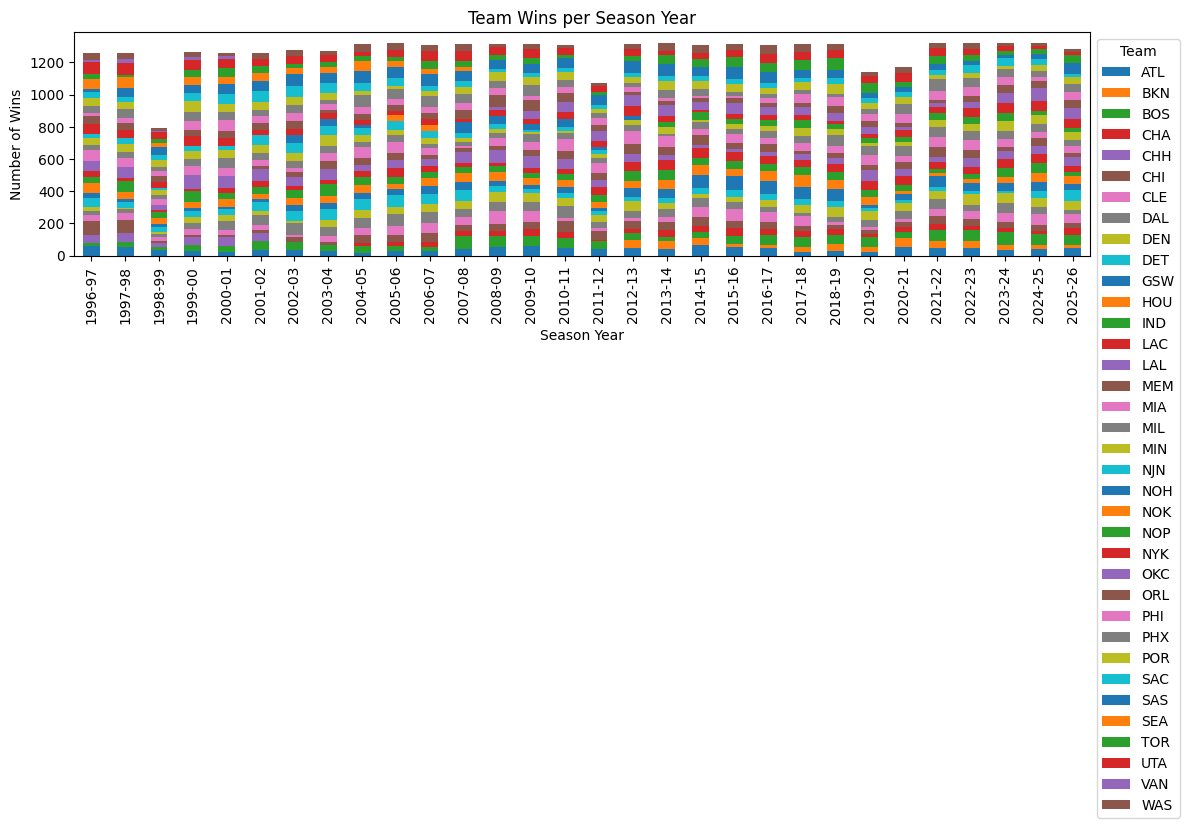

In [ ]:
# get all the wins for each team from games_index 
team_wins = games_index["winner"].value_counts()
print("Team Wins:")
display(team_wins)

# bar plot of team wins per season year
team_wins_per_year = games_index.groupby(["season_year", "winner"]).size().unstack(fill_value=0)
team_wins_per_year.plot(kind="bar", stacked=True, figsize=(12, 6))
plt.xlabel("Season Year")
plt.ylabel("Number of Wins")
plt.title("Team Wins per Season Year")
plt.legend(title="Team", bbox_to_anchor=(1, 1), loc='upper left')
plt.tight_layout()
plt.show()